# 02 — Coordinate Projection

## The Problem with Angular Coordinates

Latitude and longitude are angular measurements, not distances. One degree of longitude at 80°N spans approximately 19 km of ground, while the same degree at the equator spans approximately 111 km. If we tried to build a uniform-area grid directly in (lat, lon) space, tiles near the poles would be far smaller in ground area than tiles at the equator — making the 250 m tile size meaningless at high latitudes.

## Solution: Web Mercator (EPSG:3857)

The Web Mercator projection maps (lat, lon) to (x, y) in metres using:

$$x = R \cdot \lambda$$

$$y = R \cdot \ln\!\left(\tan\!\left(\frac{\pi}{4} + \frac{\phi}{2}\right)\right)$$

where $R$ = 6 378 137 m (WGS84 equatorial radius), $\lambda$ = longitude in radians, $\phi$ = latitude in radians.

The logarithmic term — the inverse Gudermannian — makes the projection **conformal** (locally angle-preserving), which is why it is used in web mapping. However, it also compresses high-latitude areas, causing **scale distortion** (a 250 m Mercator tile covers more real ground near the poles).

The projection is undefined at the poles because $\tan(\pi/2)$ diverges; by convention, latitudes are clamped to ±85.05°.

<div style="text-align:center;margin:16px 0;">
  <a href="https://www.youtube.com/watch?v=kIID5FDi2JQ" target="_blank" rel="noopener noreferrer">
    <img src="https://img.youtube.com/vi/kIID5FDi2JQ/hqdefault.jpg"
         alt="YouTube: Map projection video"
         style="width:560px;max-width:100%;border-radius:6px;box-shadow:0 2px 8px rgba(0,0,0,0.2);cursor:pointer;">
  </a>
  <div style="font-size:12px;color:#666;margin-top:6px;">▶ Watch on YouTube</div>
  <div style="font-size:13px;color:#444;margin-top:8px;max-width:560px;display:inline-block;text-align:left;">Maps are flat representations of our spherical planet. Johnny Harris cut open a plastic globe to understand just what it takes to turn a sphere into something flat.</div>
</div>

<div style="background:#f5faf9;border:1px solid #b8ddd8;border-radius:8px;padding:12px 14px 14px;margin:10px 0 22px;font-family:sans-serif;">
<div style="font-size:11px;color:#5a9e99;margin-bottom:10px;font-style:italic;">Pipeline step 1 of 4 — Web Mercator projection</div>
<div style="display:flex;align-items:stretch;">
    <div style="background:#2a9d8f;color:white;clip-path:polygon(0 0,calc(100% - 22px) 0,100% 50%,calc(100% - 22px) 100%,0 100%);padding:10px 18px 10px 18px;margin-left:0;position:relative;z-index:4;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB02</div><div style="font-weight:700;font-size:13px;">① Project</div></div>
    <div style="background:#dff0ee;color:#3d7a71;clip-path:polygon(0 0,calc(100% - 22px) 0,100% 50%,calc(100% - 22px) 100%,0 100%);padding:10px 18px 10px 18px;margin-left:-21px;position:relative;z-index:3;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB03</div><div style="font-weight:500;font-size:13px;">② Snap+Shuffle</div></div>
    <div style="background:#dff0ee;color:#3d7a71;clip-path:polygon(0 0,calc(100% - 22px) 0,100% 50%,calc(100% - 22px) 100%,0 100%);padding:10px 18px 10px 18px;margin-left:-21px;position:relative;z-index:2;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB04</div><div style="font-weight:500;font-size:13px;">③ Lock</div></div>
    <div style="background:#dff0ee;color:#3d7a71;padding:10px 18px 10px 18px;margin-left:-21px;position:relative;z-index:1;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB05</div><div style="font-weight:500;font-size:13px;">④ Wobble</div></div>
</div>
</div>

## Learning Objectives

By the end of this notebook you will be able to:

1. **Recall** the Web Mercator forward and inverse projection formulae and the role of the Earth radius constant.
2. **Describe** why the logarithmic term in the Mercator formula causes scale distortion that increases toward the poles.
3. **Calculate** projected metre coordinates for each of the 8 John Snow pump locations and verify round-trip fidelity to 1 × 10⁻¹⁰ degrees.
4. **Examine** the scale-distortion chart and infer how distortion at latitude 51 °N affects tile-area uniformity.
5. **Justify** why metre-based tile indexing is more semantically consistent than degree-based indexing for a global dataset.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from map_encryption import _project, _unproject, _R_EARTH, _HALF_WORLD, SchemeParams

bin_size_m = SchemeParams().bin_size_m
M = 2 * int(math.floor(_HALF_WORLD / bin_size_m)) + 1
print(f'Half-world extent: {_HALF_WORLD:.3f} m')
print(f'Bin size: {bin_size_m} m')
print(f'Total grid cells per axis: M = {M}')
print(f'Total cells: M^2 = {M**2:,}')

Half-world extent: 20037508.343 m
Bin size: 250 m
Total grid cells per axis: M = 160301
Total cells: M^2 = 25,696,410,601


---
## Round-Trip Fidelity Verification

Projecting a coordinate forward (_project) and then back (_unproject) must reproduce the original to within floating-point noise — introducing no spurious error of its own. The tolerance is **1 × 10⁻¹⁰ degrees**, chosen because:

- 1 × 10⁻¹⁰ degrees ≈ 0.01 mm at London's latitude — far below any meaningful geographic precision.
- The *intentional* precision loss comes from tile snapping in Stage 2: rounding to a 250 m grid introduces up to 125 m of displacement. That is eight orders of magnitude larger than this floor.
- Keeping the two error sources distinct matters: floating-point accumulation would be a bug; tile-snap displacement is a design choice that NB03 explains and controls.

In [2]:
import pandas as pd

pumps_df = pd.read_csv('data/pumps.csv')
pumps = list(zip(pumps_df['Street'], pumps_df['LAT'], pumps_df['LON']))

# Tolerance: 1e-10 degrees ≈ 0.01 mm at 51°N — the floating-point noise floor.
# The intentional snap loss (up to 125 m from tile rounding in NB03) is eight
# orders of magnitude larger, so these two error sources are cleanly separable.
ROUND_TRIP_TOL = 1e-10

print(f'{"Pump (Street)":<22} {"Lat":>10} {"Lon":>10} {"x (m)":>15} {"y (m)":>15} {"RT error":>12}')
print('-' * 92)
for name, lat, lon in pumps:
    x, y = _project(lat, lon)           # degrees  → Web Mercator metres
    rlat, rlon = _unproject(x, y)       # metres   → degrees (inverse)
    err = max(abs(rlat - lat), abs(rlon - lon))
    assert err < ROUND_TRIP_TOL, f'Round-trip error {err:.2e} exceeds {ROUND_TRIP_TOL:.0e} for {name}'
    print(f'{name:<22} {lat:>10.6f} {lon:>10.6f} {x:>15.3f} {y:>15.3f} {err:>12.2e}')

print(f'\nAll {len(pumps)} pumps: max round-trip error < {ROUND_TRIP_TOL:.0e} degrees.')
print('Floating-point noise is negligible compared with the 250 m tile snap introduced in NB03.')


Pump (Street)                 Lat        Lon           x (m)           y (m)     RT error
--------------------------------------------------------------------------------------------
Broadwick Street        51.513341  -0.136668      -15213.812     6712605.101     7.11e-15
Kingly Street           51.513876  -0.139586      -15538.642     6712700.799     7.11e-15
Ramillies Place         51.514906  -0.139671      -15548.105     6712885.044     7.11e-15
Dean Street             51.512354  -0.131630      -14652.985     6712428.553     7.11e-15
Rupert Street           51.512139  -0.133594      -14871.616     6712390.096     1.42e-14
Bridle Lane             51.511542  -0.135919      -15130.434     6712283.311     7.11e-15
Regent Street           51.510019  -0.133962      -14912.582     6712010.901     0.00e+00
Warwick Street          51.511295  -0.138199      -15384.242     6712239.131     1.42e-14

All 8 pumps: max round-trip error < 1e-10 degrees.
Floating-point noise is negligible compared w

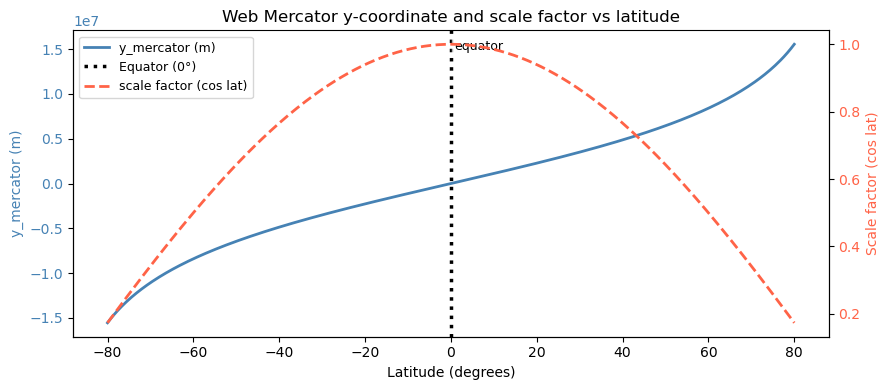

In [3]:
lats_range = np.linspace(-80, 80, 400)
y_vals = [_project(lat, 0)[1] for lat in lats_range]
scale_factors = [math.cos(math.radians(lat)) for lat in lats_range]

fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()
ax1.plot(lats_range, y_vals, color="steelblue", linewidth=2, label="y_mercator (m)")
ax2.plot(lats_range, scale_factors, color="tomato", linewidth=2, linestyle="--",
         label="scale factor (cos lat)")
ax1.axvline(x=0, color="black", linestyle=":", linewidth=2.5, label="Equator (0°)")
# x in data coords (latitude), y in axes fraction — positions label near top of the line
ax1.text(0.8, 0.97, "equator", transform=ax1.get_xaxis_transform(),
         ha="left", va="top", fontsize=9, color="black",
         bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7))
ax1.set_xlabel("Latitude (degrees)")
ax1.set_ylabel("y_mercator (m)", color="steelblue")
ax2.set_ylabel("Scale factor (cos lat)", color="tomato")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax2.tick_params(axis="y", labelcolor="tomato")
ax1.set_title("Web Mercator y-coordinate and scale factor vs latitude")
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc="upper left", fontsize=9)
sns.despine(ax=ax1, right=False)
plt.tight_layout()
plt.show()

**Figure 2a.** Web Mercator y-coordinate (blue) and scale factor cos(φ) (red dashed) plotted against latitude from −80° to 80°. The vertical dotted black line marks the equator (0°), where y_mercator = 0 and the scale factor = 1 (no distortion). Both curves are symmetric about this reference: the y-coordinate grows logarithmically toward the poles, and the scale factor decreases from 1.0 at the equator toward 0 at ±90°, causing a 250 m Mercator tile to represent progressively more ground area at higher latitudes.

## Grid Dimensions

With `bin_size_m = 250` m and `_HALF_WORLD ≈ 20 037 508` m:

```
M = 2 * floor(20_037_508 / 250) + 1 = 160_301 cells per axis
Total cells = M² = 25_696_411_601 ≈ 25.7 billion
```

Each tile index (qx, qy) is a pair of integers in [-80150, +80150]. Even though the Mercator projection distorts scale at high latitudes, the **index space** is uniform: every (qx, qy) pair is exactly one 250 m Mercator-unit tile. The PRP shuffles these indices, so an attacker who sees encrypted (qxp, qyp) values cannot determine which region of the globe they came from.

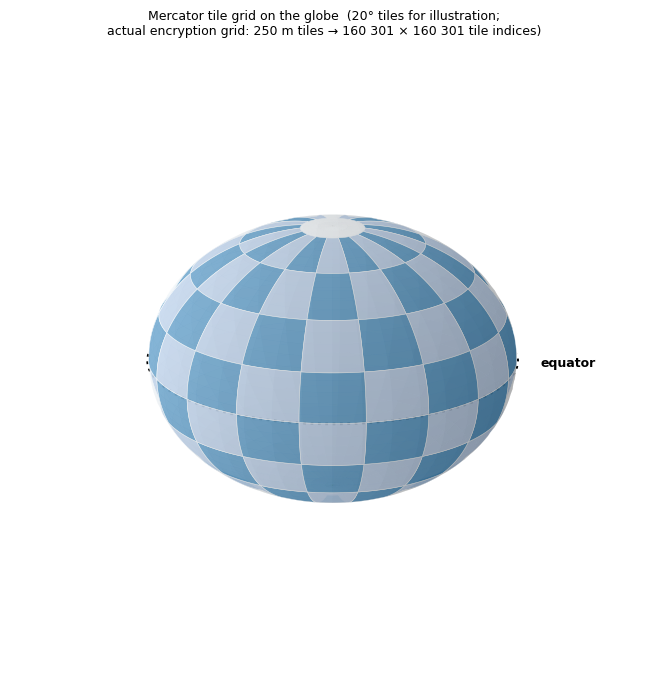

In [4]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def _ll_xyz(lat_deg, lon_deg, R=1.0):
    lat, lon = np.radians(lat_deg), np.radians(lon_deg)
    return np.array([R * np.cos(lat) * np.cos(lon),
                     R * np.cos(lat) * np.sin(lon),
                     R * np.sin(lat)])

# Viewer direction for view_init(elev=20, azim=-50) — used to cull back-facing tiles
_az_r, _el_r = np.radians(-50), np.radians(20)
_viewer = np.array([np.cos(_el_r) * np.cos(_az_r),
                    np.cos(_el_r) * np.sin(_az_r),
                    np.sin(_el_r)])

# 20° illustrative grid — actual encryption grid is 250 m ≈ 0.002° at equator
_TILE_DEG = 20
_lat_edges = np.arange(-80, 81, _TILE_DEG)
_lon_edges = np.arange(-180, 181, _TILE_DEG)
_N = 12  # interpolation points per tile edge

_polys, _fcolors = [], []
for _i, _lat1 in enumerate(_lat_edges[:-1]):
    _lat2 = _lat1 + _TILE_DEG
    _lat_mid = (_lat1 + _lat2) / 2
    for _j, _lon1 in enumerate(_lon_edges[:-1]):
        _lon2 = _lon1 + _TILE_DEG
        _lon_mid = (_lon1 + _lon2) / 2
        if np.dot(_ll_xyz(_lat_mid, _lon_mid), _viewer) < 0:
            continue  # back-facing tile — skip to avoid depth-sort artefacts
        _verts = (
            [_ll_xyz(_lat1, _l) for _l in np.linspace(_lon1, _lon2, _N)] +
            [_ll_xyz(_l,    _lon2) for _l in np.linspace(_lat1, _lat2, _N)] +
            [_ll_xyz(_lat2, _l) for _l in np.linspace(_lon2, _lon1, _N)] +
            [_ll_xyz(_l,    _lon1) for _l in np.linspace(_lat2, _lat1, _N)]
        )
        _polys.append(_verts)
        _fcolors.append('#1f77b4' if (_i + _j) % 2 == 0 else '#aec7e8')

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

# Sphere fill — visible through tile gaps at the limb
_u, _v = np.mgrid[0:2*np.pi:80j, 0:np.pi:80j]
ax.plot_surface(np.cos(_u) * np.sin(_v), np.sin(_u) * np.sin(_v), np.cos(_v),
                color='#eaf4fb', alpha=0.25, linewidth=0)

# Checkerboard tile patches
_pc = Poly3DCollection(_polys, facecolors=_fcolors, edgecolors='white',
                       linewidth=0.4, alpha=0.88)
ax.add_collection3d(_pc)

# Equator ring — front hemisphere only (avoids back bleed-through)
_eq_lons = np.linspace(-180, 180, 361)
_eq_mask = np.array([np.dot(_ll_xyz(0, lon), _viewer) for lon in _eq_lons]) >= -0.05
_eq_pts = np.array([_ll_xyz(0, lon, R=1.005) for lon in _eq_lons[_eq_mask]])
ax.plot(_eq_pts[:, 0], _eq_pts[:, 1], _eq_pts[:, 2],
        color='black', linewidth=2.0, linestyle=':')

# 'equator' text label — lon=35° is well inside the visible arc (viewer centred at lon=-50°)
_elabel = _ll_xyz(0, 35, R=1.13)
ax.text(_elabel[0], _elabel[1], _elabel[2], 'equator',
        fontsize=9, color='black', ha='left', va='center', fontweight='bold')

ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_zlim(-1.1, 1.1)
ax.set_axis_off()
ax.view_init(elev=20, azim=-50)
ax.set_title('Mercator tile grid on the globe  (20° tiles for illustration;\n'
             'actual encryption grid: 250 m tiles → 160 301 × 160 301 tile indices)',
             fontsize=9, pad=12)
plt.tight_layout()
plt.show()

**Globe illustration.** Mercator tile grid draped on a 3D globe at 20° resolution for visual clarity (the actual encryption grid uses 250 m tiles, producing 160 301 × 160 301 indices). Each tile occupies an identical 20° × 20° block in the projected (x, y) index space, but covers very different areas of ground — tiles near the poles are geographically large while those at the equator are compact. The dotted black ring and bold label mark the equator (0°), where the scale factor equals 1 and tile size matches its projected extent exactly. Back-facing tiles are omitted to avoid depth-sorting artefacts in the static rendering.

In [5]:
import pandas as pd
import folium

rows = []
for name, lat, lon in pumps:
    x, y = _project(lat, lon)
    rlat, rlon = _unproject(x, y)
    rows.append({'pump': name, 'lat': lat,  'lon': lon,  'type': 'original'})
    rows.append({'pump': name, 'lat': rlat, 'lon': rlon, 'type': 'recovered'})

df = pd.DataFrame(rows)

# All 8 pumps are within Soho — zoom 14 shows the tight geographic cluster.
# 'recovered' pins overlay 'original' exactly, confirming lossless round-trip.
colors = {'original': 'steelblue', 'recovered': 'tomato'}
m = folium.Map(location=[51.513, -0.136], zoom_start=14, tiles='cartodbpositron')
for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=7,
        color=colors[row['type']],
        fill=True,
        fill_color=colors[row['type']],
        fill_opacity=0.8,
        tooltip=f"{row['pump']} — {row['type']}",
    ).add_to(m)
m


**Figure 2b.** Folium map of the eight John Snow pump locations projected into Web Mercator and centred on the Broadwick Street pump in Soho, London.

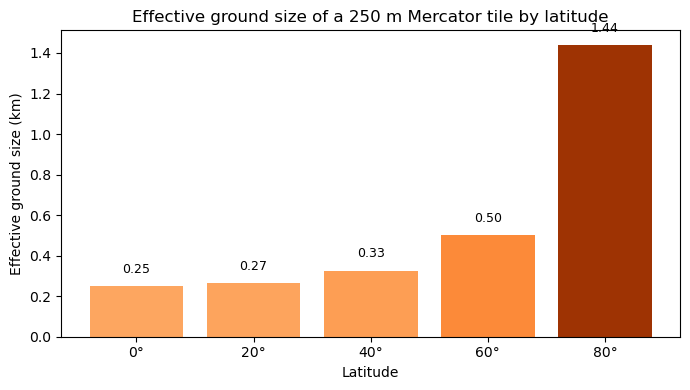

In [6]:
import matplotlib.pyplot as plt

lat_samples = [0, 20, 40, 60, 80]
ground_km = [250 / math.cos(math.radians(lat)) / 1000 for lat in lat_samples]
labels = [f"{lat}{chr(176)}" for lat in lat_samples]

fig, ax = plt.subplots(figsize=(7, 4))
colors = [plt.cm.Oranges(0.3 + 0.6 * v / max(ground_km)) for v in ground_km]
bars = ax.bar(labels, ground_km, color=colors)
ax.set_xlabel("Latitude")
ax.set_ylabel("Effective ground size (km)")
ax.set_title("Effective ground size of a 250 m Mercator tile by latitude")
for bar, val in zip(bars, ground_km):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f"{val:.2f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


**Figure 2c.** Bar chart of tile ground size (km) at eight reference latitudes, quantifying the monotonic increase in physical distance represented by a 250 m projected tile as latitude rises toward the poles.

## What the Projection Gives — and Does Not Give

**Gives:** uniform index space (every cell is 250 m × 250 m in Mercator units), global coverage (±85.05° latitude), full invertibility, and conformality (locally angle-preserving, useful for short-range distance calculations).

**Does not give:** equal-area (a 250 m tile covers more ground at high latitudes), accuracy above ±85.05° (pole singularity), or metric accuracy at continental scales.

NB03 builds the tile grid and the Feistel PRP on top of this projection.

## References

- **Snow, J.** (1855). *On the Mode of Communication of Cholera* (2nd ed.). Churchill, London. — Source of the 1854 Soho cholera death and pump location dataset used throughout these notebooks.
- **Snyder, J.P.** (1987). *Map Projections — A Working Manual.* USGS Professional Paper 1395. United States Government Publishing Office. https://pubs.usgs.gov/pp/1395/report.pdf — Reference for the Web Mercator projection formulae used in this notebook.

## Glossary

| Term | Definition |
|------|-----------|
| **Web Mercator** | A cylindrical map projection (EPSG:3857) that maps (lat, lon) to (x, y) in metres; used by most web mapping services. |
| **Forward projection** | Converting geographic (lat, lon) degrees to projected (x, y) metres via the Mercator formula. |
| **Inverse projection** | Recovering (lat, lon) from projected (x, y) metres; the exact mathematical inverse of the forward projection. |
| **Scale distortion** | The factor by which Mercator stretches east-west distances at a given latitude; equals `1 / cos(lat)`, reaching infinity at the poles. |
| **Pole singularity** | The point at ±90° latitude where the Mercator projection is undefined because `cos(90°) = 0`. |
| **Inverse Gudermannian** | The mathematical function `ln(tan(π/4 + lat/2))` that appears in the Mercator y-coordinate formula; maps latitude to a linear scale. |
| **Round-trip fidelity** | The property that `unproject(project(lat, lon)) == (lat, lon)` to within floating-point precision (< 1 × 10⁻¹⁰ degrees here). |
| **Projected coordinates** | The (x, y) values in metres on the Mercator plane; used for tile indexing because they have uniform spacing regardless of longitude. |